In [1]:
import numpy as np
import time
from scipy import misc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(style='normal', size=20)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_dtype(torch.float64)
import random
import math
import pandas as pd
from scipy.optimize import fsolve
# from scipy.integrate import solve_ivp # type: ignore
import scipy.integrate as integrate

import json

from IPython.display import display, Math, Markdown
import seaborn as sns
sns.set(font_scale = 2)

import pandas as pd
import datetime
import os
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
timestamp
version = '_8'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_78284/3215957732.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


Using 20 of 20 runs (0 excluded as bf_train_s outliers)


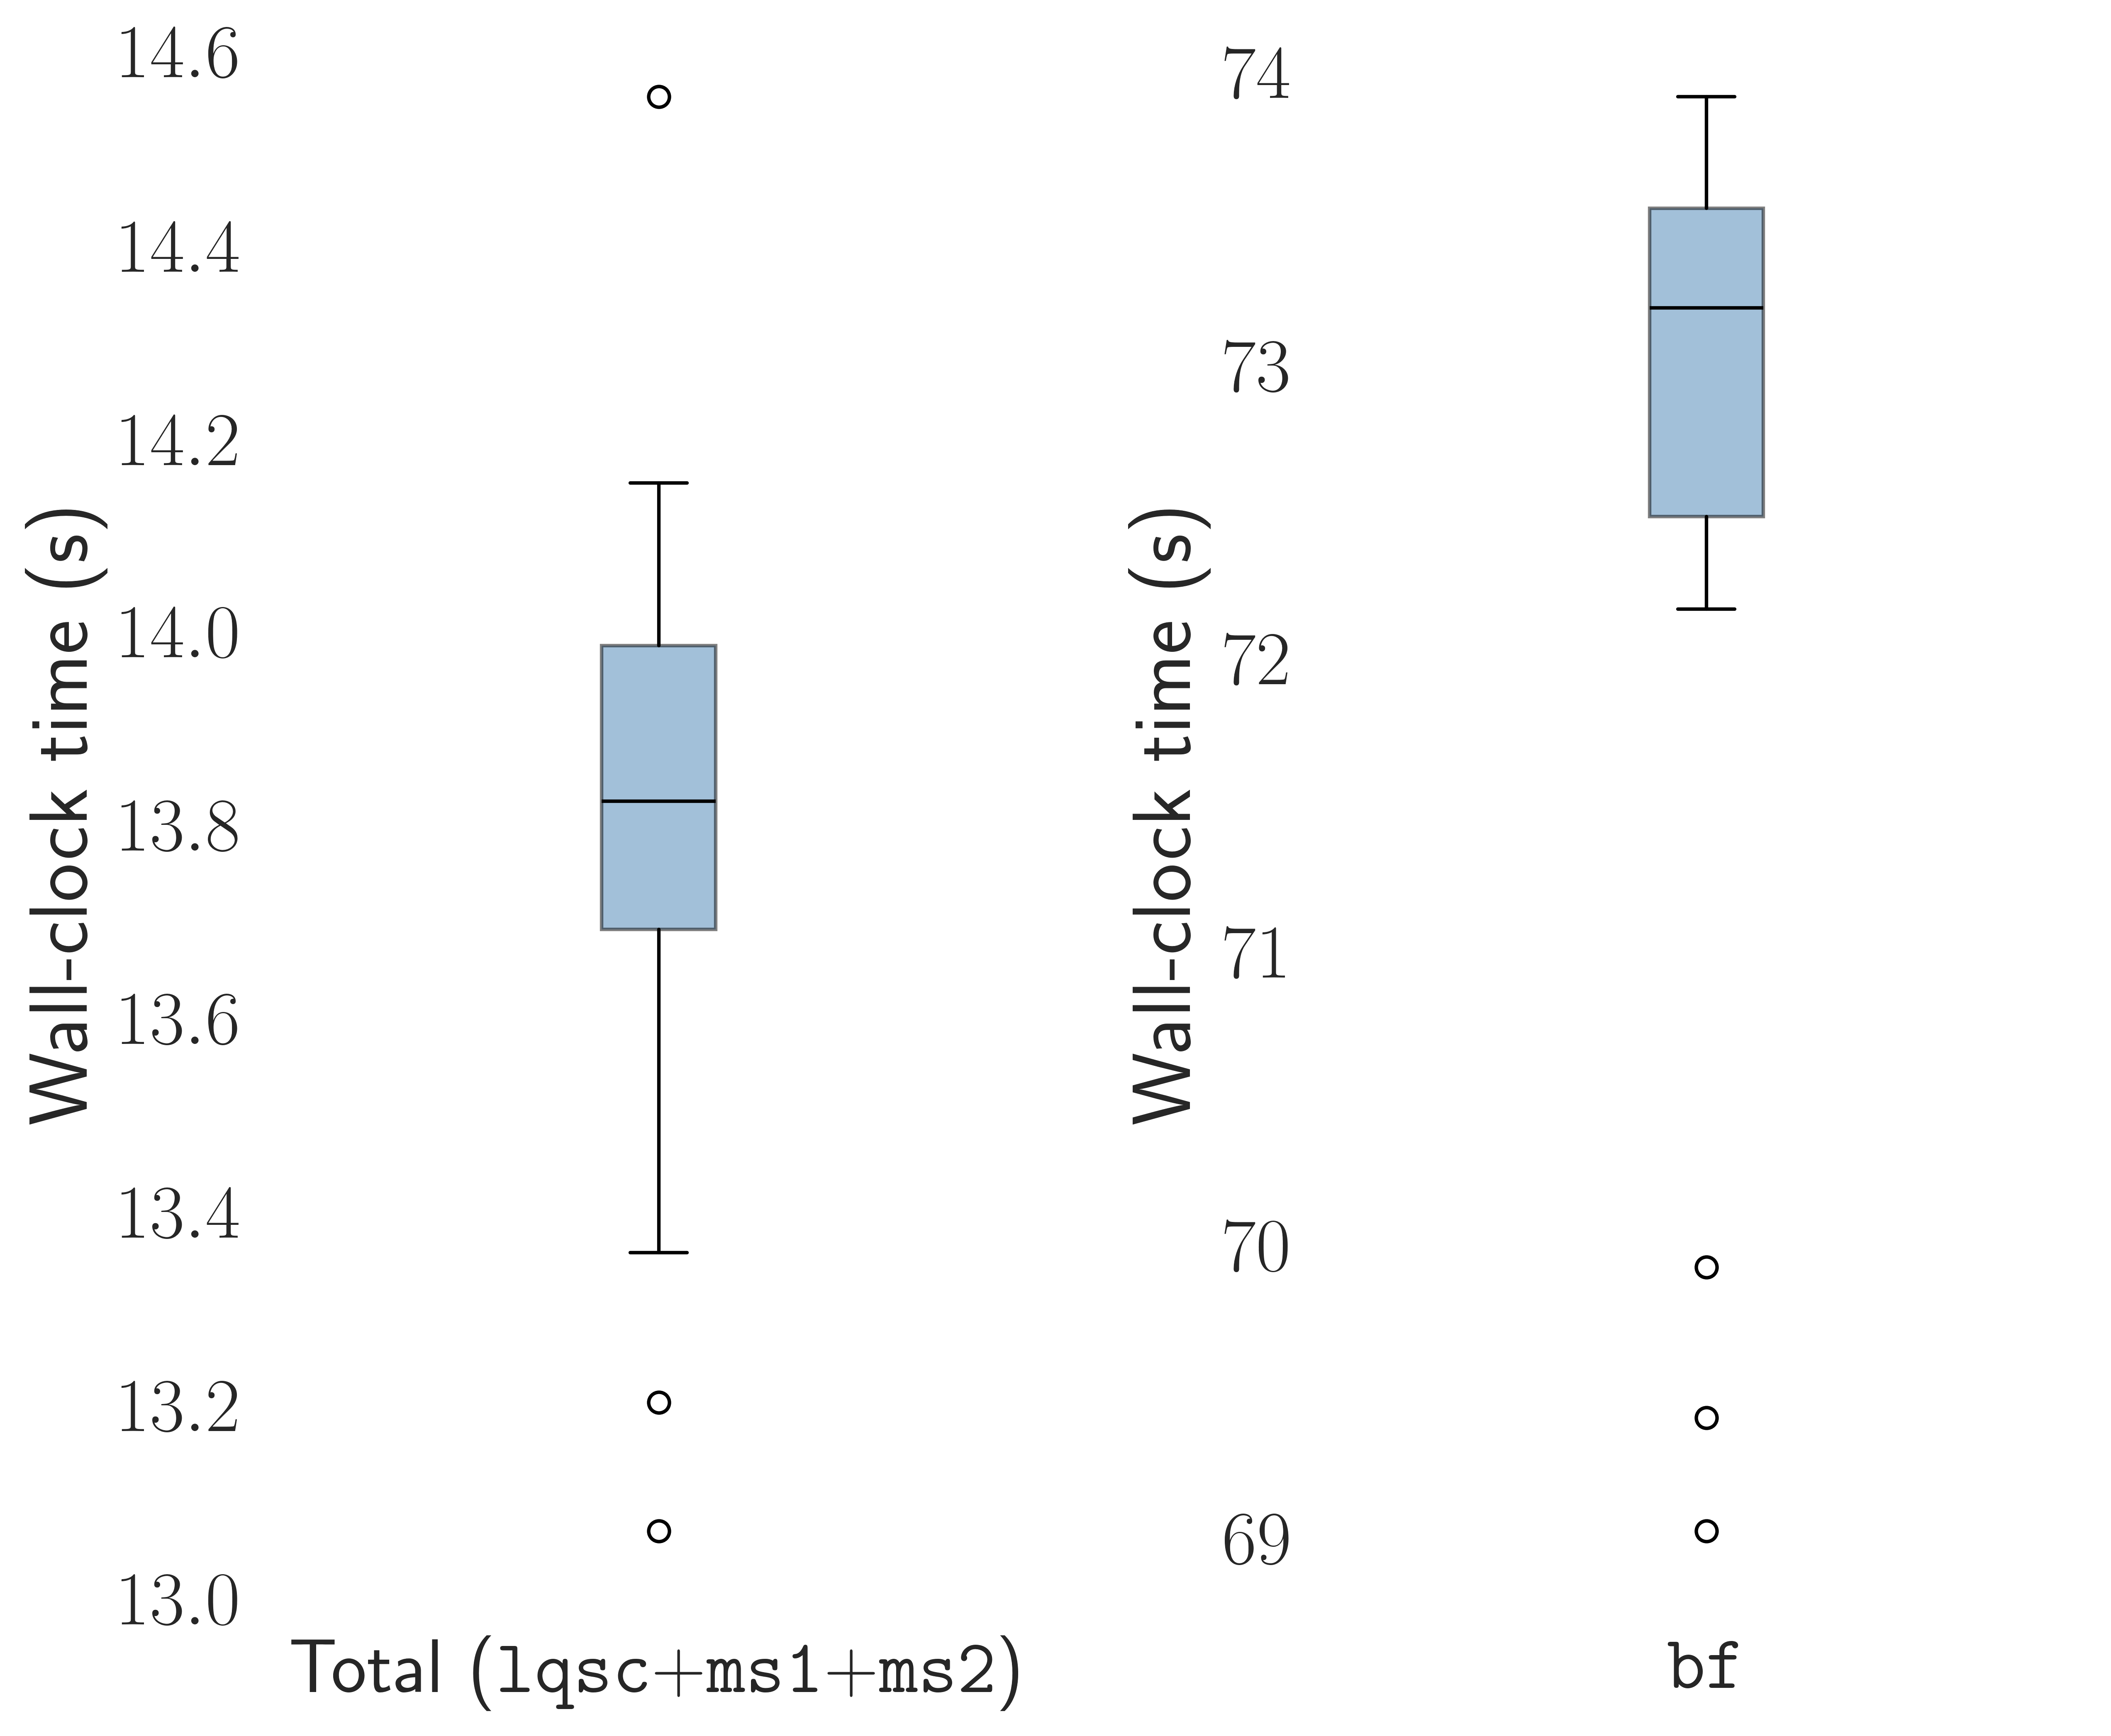

In [2]:
# Boxplot: Total (lqsc+ms1+ms2) vs bf, excluding the bf_train_s outlier runs (>=100s, clearly not typical)
# Each box gets its own y-axis (different scales -- avoids a dead gap on a shared axis)
import json as _json

with open('wallclock_log.json') as f:
    wallclock_log = _json.load(f)

all_runs = wallclock_log['runs']
runs = [r for r in all_runs if r['bf_train_s'] < 100]
n_excluded = len(all_runs) - len(runs)
print(f"Using {len(runs)} of {len(all_runs)} runs ({n_excluded} excluded as bf_train_s outliers)")

total_vals = [r['total_s'] for r in runs]
bf_vals = [r['bf_train_s'] for r in runs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7.5), dpi=600)
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

box_color = 'steelblue'
boxprops = dict(facecolor=box_color, alpha=0.5, edgecolor='black')
medianprops = dict(color='black')
whiskerprops = dict(color='black')
capprops = dict(color='black')

ax1.boxplot([total_vals], patch_artist=True,
            boxprops=boxprops, medianprops=medianprops,
            whiskerprops=whiskerprops, capprops=capprops,
            tick_labels=[r'Total ($\mathtt{lqsc}$+$\mathtt{ms1}$+$\mathtt{ms2}$)'])
ax1.set_ylabel('Wall-clock time (s)')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([bf_vals], patch_artist=True,
            boxprops=boxprops, medianprops=medianprops,
            whiskerprops=whiskerprops, capprops=capprops,
            tick_labels=[r'$\mathtt{bf}$'])
ax2.set_ylabel('Wall-clock time (s)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lqc_v8_wallclock_boxplot.png', dpi=600, bbox_inches='tight')
plt.show()